In [34]:
!pip install open3d
#!pip install plotly

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
from google.colab import drive
drive.mount('/content/drive')
zip_seed = "/content/drive/MyDrive/Seeds.zip"
label_csv = "/content/drive/MyDrive/label.csv"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
# prompt: generate code to ectract zip file and store in seed

import zipfile
import os

# Extract the zip file
with zipfile.ZipFile(zip_seed, 'r') as zip_ref:
    zip_ref.extractall("Seeds")

# Verify extraction
print(f"Contents of 'seed' directory after extraction:")
!ls Seeds

Seed_all = sorted(os.listdir("Seeds/Seeds"))
for file in Seed_all[:10]:
  print(file)

print("total no. of files are :", len(Seed_all))

Contents of 'seed' directory after extraction:
Seeds
100_20240611T081750_unitfile_1_1.ply
100_20240611T081750_unitfile_1_2.ply
100_20240611T081750_unitfile_1_3.ply
100_20240611T081750_unitfile_1_4.ply
100_20240611T081750_unitfile_1_5.ply
100_20240611T081750_unitfile_2_1.ply
100_20240611T081750_unitfile_2_2.ply
100_20240611T081750_unitfile_2_3.ply
100_20240611T081750_unitfile_2_4.ply
100_20240611T081750_unitfile_2_5.ply
total no. of files are : 1099


In [38]:
import pandas as pd

# Assuming 'label.csv' is in the correct location as defined in the previous code.
Label_DataFrame = pd.read_csv(label_csv)
Label_DataFrame = Label_DataFrame.sort_values(by=['fileanme'])

print(Label_DataFrame.head()) # Print the first few rows to verify
print(Label_DataFrame.info()) #Check some info about the dataframe
print(len(Label_DataFrame))


                                 fileanme     label
475  100_20240611T081750_unitfile_1_1.ply  Sudanese
476  100_20240611T081750_unitfile_1_2.ply  Sudanese
477  100_20240611T081750_unitfile_1_3.ply  Sudanese
478  100_20240611T081750_unitfile_1_4.ply  Sudanese
479  100_20240611T081750_unitfile_1_5.ply  Sudanese
<class 'pandas.core.frame.DataFrame'>
Index: 1099 entries, 475 to 474
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   fileanme  1099 non-null   object
 1   label     1099 non-null   object
dtypes: object(2)
memory usage: 25.8+ KB
None
1099


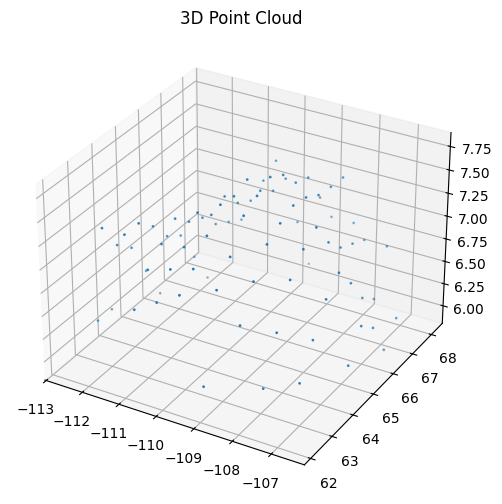

No. of points in  100_20240611T081750_unitfile_1_1.ply is 87


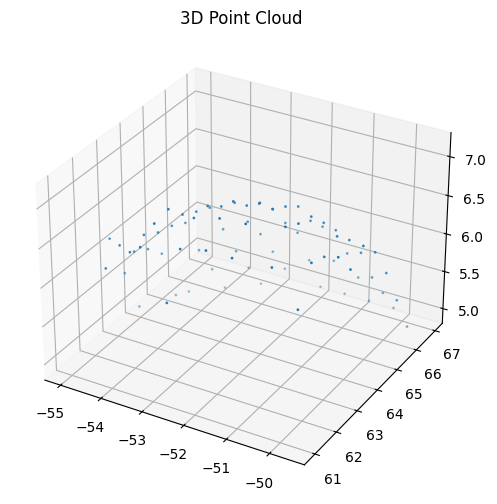

No. of points in  100_20240611T081750_unitfile_1_2.ply is 83


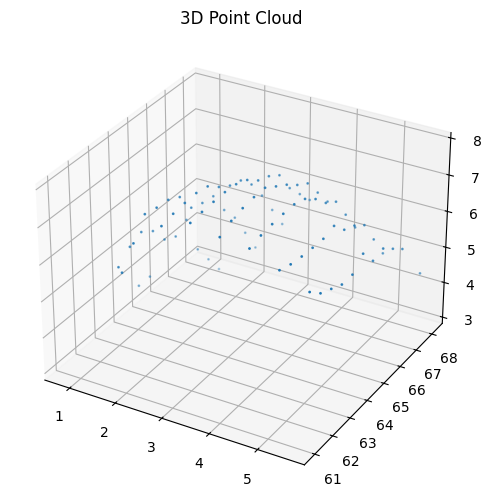

No. of points in  100_20240611T081750_unitfile_1_3.ply is 93
No. of points in  100_20240611T081750_unitfile_1_1.ply is 87
No. of points in  100_20240611T081750_unitfile_1_2.ply is 83
No. of points in  100_20240611T081750_unitfile_1_3.ply is 93
No. of points in  100_20240611T081750_unitfile_1_4.ply is 70
No. of points in  100_20240611T081750_unitfile_1_5.ply is 69
No. of points in  100_20240611T081750_unitfile_2_1.ply is 72
No. of points in  100_20240611T081750_unitfile_2_2.ply is 98
No. of points in  100_20240611T081750_unitfile_2_3.ply is 114
No. of points in  100_20240611T081750_unitfile_2_4.ply is 99
No. of points in  100_20240611T081750_unitfile_2_5.ply is 67
No. of points in  100_20240611T081750_unitfile_3_1.ply is 51
No. of points in  100_20240611T081750_unitfile_3_2.ply is 73
No. of points in  100_20240611T081750_unitfile_3_3.ply is 52
No. of points in  100_20240611T081750_unitfile_3_4.ply is 37
No. of points in  100_20240611T081750_unitfile_3_5.ply is 48
No. of points in  100_2

In [39]:
# prompt: write code to diplay the .ply in 3d space using trimesh
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import os

# Assuming Seed_all is defined from the previous code block
# Example usage with the first .ply file
for file in Seed_all[:3]:  # Iterate through the first 10 files
  if file.endswith(".ply"):
    filepath = os.path.join("Seeds/Seeds", file)
    try:
      pcd = o3d.io.read_point_cloud(filepath)
      points = np.asarray(pcd.points)

      fig = plt.figure(figsize=(8, 6))
      ax = fig.add_subplot(111, projection='3d')
      ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1)
      ax.set_title('3D Point Cloud')
      plt.show()
      print("No. of points in ",file ,"is", len(pcd.points))  # May work in some Colab setups
    except Exception as e:
        print(f"Error processing {file}: {e}")



for file in Seed_all[:]:  # Iterate through the first 10 files
  if file.endswith(".ply"):
    filepath = os.path.join("Seeds/Seeds", file)
    try:
      pcd = o3d.io.read_point_cloud(filepath)
      points = np.asarray(pcd.points)

      print("No. of points in ",file ,"is", len(pcd.points))  # May work in some Colab setups
    except Exception as e:
        print(f"Error processing {file}: {e}")


In [40]:
import open3d as o3d
import os
import shutil

# Paths
src_dir = "Seeds/Seeds"
dst_dir = "Seeds_cleaned/Seeds"

# Create destination directory if it doesn't exist
os.makedirs(dst_dir, exist_ok=True)

deleted_files = []
copied_files = []

for file in os.listdir(src_dir):
    if file.endswith(".ply"):
        src_path = os.path.join(src_dir, file)
        try:
            pcd = o3d.io.read_point_cloud(src_path)
            if len(pcd.points) == 0:
                os.remove(src_path)
                deleted_files.append(file)
                print(f"Deleted empty file: {file}")
            else:
                # Copy non-empty file to cleaned directory
                dst_path = os.path.join(dst_dir, file)
                shutil.copy2(src_path, dst_path)
                copied_files.append(file)
                print(f"Copied non-empty file to cleaned folder: {file}")
        except Exception as e:
            print(f"Error processing {file}: {e}")

print(f"\n✅ Completed. {len(deleted_files)} files deleted. {len(copied_files)} files copied.")


Copied non-empty file to cleaned folder: 113_20240611T112739_unitfile_1_2.ply
Copied non-empty file to cleaned folder: 82_20240610T084139_unitfile_3_4.ply
Copied non-empty file to cleaned folder: 105_20240611T090549_unitfile_4_5.ply
Copied non-empty file to cleaned folder: 124_20240611T115828_unitfile_2_3.ply
Copied non-empty file to cleaned folder: 104_20240611T090305_unitfile_2_2.ply
Copied non-empty file to cleaned folder: 96_20240610T115720_unitfile_2_1.ply
Copied non-empty file to cleaned folder: 105_20240611T090549_unitfile_2_1.ply
Copied non-empty file to cleaned folder: 92_20240610T113048_unitfile_5_2.ply
Copied non-empty file to cleaned folder: 89_20240610T111249_unitfile_3_2.ply
Copied non-empty file to cleaned folder: 88_20240610T093946_unitfile_2_5.ply
Copied non-empty file to cleaned folder: 119_20240611T114436_unitfile_5_3.ply
Copied non-empty file to cleaned folder: 123_20240611T115621_unitfile_3_4.ply
Copied non-empty file to cleaned folder: 91_20240610T112551_unitfile_

In [41]:
import pandas as pd

# Path to the label CSV
csv_path = "drive/MyDrive/label.csv"

# Load the CSV
df = pd.read_csv(csv_path)

# Remove rows with deleted files
filtered_df = df[~df['fileanme'].isin(deleted_files)]

# (Optional) Save to new CSV or overwrite
filtered_df.to_csv("drive/MyDrive/labels_cleaned.csv", index=False)

print(f"\nUpdated label file. Removed {len(deleted_files)} entries.")



Updated label file. Removed 29 entries.


In [42]:
import open3d as o3d
import os

# Path to cleaned .ply files
cleaned_dir = "Seeds_cleaned/Seeds"

point_counts = []
file_point_map = {}

for file in os.listdir(cleaned_dir):
    if file.endswith(".ply"):
        filepath = os.path.join(cleaned_dir, file)
        try:
            pcd = o3d.io.read_point_cloud(filepath)
            num_points = len(pcd.points)
            point_counts.append(num_points)
            file_point_map[file] = num_points
        except Exception as e:
            print(f"Error reading {file}: {e}")

# Get min and max
if point_counts:
    min_points = min(point_counts)
    max_points = max(point_counts)

    min_files = [f for f, c in file_point_map.items() if c == min_points]
    max_files = [f for f, c in file_point_map.items() if c == max_points]

    print(f"\n📉 Minimum points: {min_points} in files: {min_files}")
    print(f"📈 Maximum points: {max_points} in files: {max_files}")
else:
    print("No point clouds found in the cleaned folder.")



📉 Minimum points: 37 in files: ['100_20240611T081750_unitfile_3_4.ply', '123_20240611T115621_unitfile_2_4.ply']
📈 Maximum points: 331 in files: ['116_20240611T113538_unitfile_1_2.ply']


In [43]:
from sklearn.model_selection import train_test_split
import os
import torch
import pandas as pd
import numpy as np
import open3d as o3d
from torch.utils.data import Dataset


class PointCloudDataset(Dataset):
    def __init__(self, ply_dir, label_csv, num_points=256, transform=None, split='train', test_size=0.2, random_state=42):
        self.ply_dir = ply_dir
        self.num_points = num_points
        self.transform = transform

        # Load labels
        df = pd.read_csv(label_csv)

        # Check if there are exactly two unique classes
        unique_labels = df['label'].unique()
        if len(unique_labels) != 2:
            raise ValueError("The dataset must have exactly two unique labels for binary classification.")

        # Map the two labels to 0 and 1
        label_map = {unique_labels[0]: 0, unique_labels[1]: 1}
        print(f"Label mapping: {label_map}")
        df['label'] = df['label'].map(label_map)

        # Train/test split
        train_df, test_df = train_test_split(
            df,
            test_size=test_size,
            stratify=df['label'],
            random_state=random_state
        )

        if split == 'train':
            selected_df = train_df
        elif split == 'test':
            selected_df = test_df
        else:
            raise ValueError("split must be 'train' or 'test'")

        self.filenames = selected_df['fileanme'].values
        self.labels = selected_df['label'].values

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        ply_path = os.path.join(self.ply_dir, self.filenames[idx])
        pcd = o3d.io.read_point_cloud(ply_path)
        points = np.asarray(pcd.points)

        if len(points) == 0:
            raise ValueError(f"Empty point cloud: {ply_path}")

        # Sampling
        if len(points) >= self.num_points:
            sampled_idx = np.random.choice(len(points), self.num_points, replace=False)
        else:
            sampled_idx = np.random.choice(len(points), self.num_points, replace=True)
        sampled_points = points[sampled_idx]

        # Normalize
        sampled_points = sampled_points - np.mean(sampled_points, axis=0)
        norm = np.max(np.linalg.norm(sampled_points, axis=1))
        if norm > 0:
            sampled_points = sampled_points / norm

        point_tensor = torch.from_numpy(sampled_points).float()
        label_tensor = torch.tensor(self.labels[idx]).long()

        if self.transform:
            point_tensor = self.transform(point_tensor)

        return point_tensor, label_tensor


In [44]:
train_dataset = PointCloudDataset(ply_dir="/content/Seeds_cleaned/Seeds/", label_csv="drive/MyDrive/labels_cleaned.csv", split='train')
test_dataset = PointCloudDataset(ply_dir='path/to/plys', label_csv="drive/MyDrive/labels_cleaned.csv", split='test')


Label mapping: {'Ethiopian': 0, 'Sudanese': 1}
Label mapping: {'Ethiopian': 0, 'Sudanese': 1}


In [45]:
from torch.utils.data import DataLoader

dataset = PointCloudDataset(
    ply_dir="Seeds_cleaned/Seeds",
    label_csv="drive/MyDrive/labels_cleaned.csv",
    num_points=256
)

dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

for points, labels in dataloader:
    print("Point cloud batch shape:", points.shape)  # [B, 1024, 3]
    print("Labels:", labels)
    break


Label mapping: {'Ethiopian': 0, 'Sudanese': 1}
Point cloud batch shape: torch.Size([16, 256, 3])
Labels: tensor([0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0])


In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def square_distance(src, dst):
    return torch.sum((src[:, :, None] - dst[:, None]) ** 2, dim=-1)

def index_points(points, idx):
    B = points.shape[0]
    batch_indices = torch.arange(B, dtype=torch.long).to(points.device).view(B, 1, 1)
    return points[batch_indices, idx, :]

def farthest_point_sample(xyz, npoint):
    B, N, C = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long).to(xyz.device)
    distance = torch.ones(B, N).to(xyz.device) * 1e10
    farthest = torch.randint(0, N, (B,), dtype=torch.long).to(xyz.device)

    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = index_points(xyz, farthest.view(-1, 1)).view(B, 1, C)
        dist = torch.sum((xyz - centroid) ** 2, -1)
        mask = dist < distance
        distance[mask] = dist[mask]
        farthest = torch.max(distance, -1)[1]
    return centroids

def query_ball_point(radius, nsample, xyz, new_xyz):
    sqrdists = square_distance(new_xyz, xyz)
    group_idx = sqrdists.argsort()[:, :, :nsample]

    # Debugging: Print the shapes of the variables involved
    print(f"new_xyz shape: {new_xyz.shape}")  # Should be [B, npoint, 3]
    print(f"xyz shape: {xyz.shape}")  # Should be [B, N, 3]
    print(f"sqrdists shape: {sqrdists.shape}")  # Should be [B, npoint, N]
    print(f"group_idx shape: {group_idx.shape}")  # Should be [B, npoint, nsample]

    return group_idx

def sample_and_group(npoint, radius, nsample, xyz, points):
    B, N, C = xyz.shape
    S = npoint
    print(f"Initial xyz shape: {xyz.shape}")  # [B, N, 3]

    fps_idx = farthest_point_sample(xyz, npoint)
    print(f"fps_idx shape: {fps_idx.shape}")  # [B, npoint]

    new_xyz = index_points(xyz, fps_idx)
    print(f"new_xyz shape after FPS: {new_xyz.shape}")  # [B, npoint, 3]

    idx = query_ball_point(radius, nsample, xyz, new_xyz)
    print(f"idx shape after query_ball_point: {idx.shape}")  # [B, npoint, nsample]

    grouped_xyz = index_points(xyz, idx)
    print(f"grouped_xyz shape after index_points: {grouped_xyz.shape}")  # [B, npoint, nsample, 3]

    grouped_xyz -= new_xyz.view(B, S, 1, C)
    print(f"grouped_xyz shape after subtracting new_xyz: {grouped_xyz.shape}")  # [B, npoint, nsample, 3]

    if points is not None:
        grouped_points = index_points(points, idx)
        print(f"grouped_points shape after index_points: {grouped_points.shape}")  # [B, npoint, nsample, C]

        new_points = torch.cat([grouped_xyz, grouped_points], dim=-1)
        print(f"new_points shape after concatenation: {new_points.shape}")  # [B, npoint, nsample, 3+C]
    else:
        new_points = grouped_xyz
        print(f"new_points shape (only grouped_xyz): {new_points.shape}")  # [B, npoint, nsample, 3]

    return new_xyz, new_points



In [47]:
import torch
import torch.nn as nn

# Dummy Data (You can replace these with your actual data)
B = 2  # Batch size
N = 12  # Number of points per point cloud (adjust this)
C = 3  # Number of channels (coordinates)
npoint = 2  # Number of centroids you want to sample
radius = 0.1  # Ball query radius
nsample = 3  # Number of samples in each neighborhood

# Create random point cloud data for debugging
xyz = torch.randn(B, N, 3).float()  # Shape: [B, N, 3]
points = torch.randn(B, N, C).float()  # Shape: [B, N, 3]

print(f"Initial xyz shape: {xyz.shape}")  # Expected: [B, N, 3]
print(f"Initial points shape: {points.shape}")  # Expected: [B, N, 3]

# Helper functions
def index_points(points, idx):
    """
    Input:
        points: [B, N, C]
        idx: [B, ..., S]  (e.g., [B, npoint], or [B, npoint, nsample])
    Return:
        new_points: [B, ..., S, C]
    """
    B = points.shape[0]
    view_shape = list(idx.shape)
    view_shape.append(points.shape[-1])  # append C
    batch_indices = torch.arange(B, dtype=torch.long).to(points.device).view(B, *((1,) * (idx.dim() - 1)))
    new_points = points[batch_indices, idx]
    return new_points.view(*view_shape)


def farthest_point_sample(xyz, npoint):
    B, N, C = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long).to(xyz.device)
    distance = torch.ones(B, N).to(xyz.device) * 1e10
    farthest = torch.randint(0, N, (B,), dtype=torch.long).to(xyz.device)

    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = index_points(xyz, farthest.unsqueeze(1))  # Fixed here
        dist = torch.sum((xyz - centroid) ** 2, -1)
        mask = dist < distance
        distance[mask] = dist[mask]
        farthest = torch.max(distance, -1)[1]

    return centroids

def query_ball_point(radius, nsample, xyz, new_xyz):
    # Check shape of new_xyz (should be [B, npoint, 3]) and xyz (should be [B, N, 3])
    print(f"new_xyz shape: {new_xyz.shape}")  # Expected: [B, npoint, 3]
    print(f"xyz shape: {xyz.shape}")  # Expected: [B, N, 3]

    # Calculate squared distances between new_xyz and xyz
    sqrdists = torch.sum((new_xyz[:, :, None, :] - xyz[:, None, :, :]) ** 2, -1)  # Shape: [B, npoint, N]
    print(f"Squared distances shape: {sqrdists.shape}")  # Should be [B, npoint, N]

    group_idx = sqrdists.argsort()[:, :, :nsample]  # Shape: [B, npoint, nsample]
    return group_idx

def sample_and_group(npoint, radius, nsample, xyz, points):
    B, N, C = xyz.shape
    S = npoint

    print("Before farthest_point_sample:")
    print(f"xyz shape: {xyz.shape}")  # Expected: [B, N, 3]

    fps_idx = farthest_point_sample(xyz, npoint)  # Get farthest point sample indices
    print(f"Farthest point sample indices: {fps_idx.shape}")  # Expected: [B, npoint]

    new_xyz = index_points(xyz, fps_idx)  # Shape: [B, npoint, 3]
    print(f"new_xyz after farthest point sampling: {new_xyz.shape}")

    idx = query_ball_point(radius, nsample, xyz, new_xyz)  # Get indices of neighbors
    print(f"Query ball point indices: {idx.shape}")  # Expected: [B, npoint, nsample]

    grouped_xyz = index_points(xyz, idx)  # Shape: [B, npoint, nsample, 3]
    print(f"Grouped xyz points: {grouped_xyz.shape}")  # Expected: [B, npoint, nsample, 3]

    grouped_xyz -= new_xyz.view(B, S, 1, C)  # Normalize by centroids
    print(f"Normalized grouped xyz points: {grouped_xyz.shape}")  # Expected: [B, npoint, nsample, 3]

    if points is not None:
        grouped_points = index_points(points, idx)  # Group the features as well
        new_points = torch.cat([grouped_xyz, grouped_points], dim=-1)  # Concatenate xyz and features
        print(f"Grouped points: {grouped_points.shape}")  # Expected: [B, npoint, nsample, C]
    else:
        new_points = grouped_xyz

    return new_xyz, new_points

# Call sample_and_group function
new_xyz, new_points = sample_and_group(npoint, radius, nsample, xyz, points)

# Final check on shapes
print(f"new_xyz shape after grouping: {new_xyz.shape}")  # Expected: [B, npoint, 3]
print(f"new_points shape after grouping: {new_points.shape}")  # Expected: [B, npoint, nsample, 3 + C]


Initial xyz shape: torch.Size([2, 12, 3])
Initial points shape: torch.Size([2, 12, 3])
Before farthest_point_sample:
xyz shape: torch.Size([2, 12, 3])
Farthest point sample indices: torch.Size([2, 2])
new_xyz after farthest point sampling: torch.Size([2, 2, 3])
new_xyz shape: torch.Size([2, 2, 3])
xyz shape: torch.Size([2, 12, 3])
Squared distances shape: torch.Size([2, 2, 12])
Query ball point indices: torch.Size([2, 2, 3])
Grouped xyz points: torch.Size([2, 2, 3, 3])
Normalized grouped xyz points: torch.Size([2, 2, 3, 3])
Grouped points: torch.Size([2, 2, 3, 3])
new_xyz shape after grouping: torch.Size([2, 2, 3])
new_points shape after grouping: torch.Size([2, 2, 3, 6])


In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PointNetSetAbstractionMSG(nn.Module):
    def __init__(self, npoint, radius_list, nsample_list, in_channel, mlp_list):
        super().__init__()
        self.npoint = npoint
        self.radius_list = radius_list
        self.nsample_list = nsample_list
        self.conv_blocks = nn.ModuleList()
        self.bn_blocks = nn.ModuleList()

        for i in range(len(radius_list)):
            mlps = [in_channel] + mlp_list[i]
            convs = nn.ModuleList()
            bns = nn.ModuleList()
            for j in range(len(mlps)-1):
                convs.append(nn.Conv2d(mlps[j], mlps[j+1], 1))
                bns.append(nn.BatchNorm2d(mlps[j+1]))
            self.conv_blocks.append(convs)
            self.bn_blocks.append(bns)

    def forward(self, xyz, points):
        B, N, C = xyz.shape
        S = self.npoint
        new_xyz = index_points(xyz, farthest_point_sample(xyz, S))
        new_points_list = []

        for i, radius in enumerate(self.radius_list):
            nsample = self.nsample_list[i]
            idx = query_ball_point(radius, nsample, xyz, new_xyz)
            grouped_xyz = index_points(xyz, idx) - new_xyz.view(B, S, 1, C)
            if points is not None:
                grouped_points = index_points(points, idx)
                grouped_points = torch.cat([grouped_points, grouped_xyz], dim=-1)
            else:
                grouped_points = grouped_xyz
            grouped_points = grouped_points.permute(0, 3, 2, 1)  # [B, D, K, S]

            for j in range(len(self.conv_blocks[i])):
                conv = self.conv_blocks[i][j]
                bn = self.bn_blocks[i][j]
                grouped_points = F.relu(bn(conv(grouped_points)))
            new_points = torch.max(grouped_points, 2)[0]
            new_points_list.append(new_points)

        return new_xyz, torch.cat(new_points_list, dim=1)


class PointNetClassifierMSG(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # -- sa1: stays as you had it --
        self.sa1 = PointNetSetAbstractionMSG(
            npoint=256,
            radius_list=[0.1, 0.2, 0.4],
            nsample_list=[16, 32, 128],
            in_channel=6,       # if you really want xyz as features too
            mlp_list=[[32,32,64], [64,64,128], [64,96,128]]
        )
        # Let’s assume that actually produces C1=259 channels:
        sa1_out_channels = 259

        # -- sa2: use the true sa1_out_channels --
        self.sa2 = PointNetSetAbstractionMSG(
            npoint=64,
            radius_list=[0.2, 0.4, 0.8],
            nsample_list=[32, 64, 128],
            in_channel=sa1_out_channels,
            mlp_list=[[64,64,128], [128,128,256], [128,128,256]]
        )
        # Compute how many channels sa2 spits out:
        # 128 + 256 + 256 = 640
        sa2_out_channels = 128 + 256 + 256

        # -- Fully connected layers --
        self.fc1 = nn.Linear(sa2_out_channels, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.drop1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.drop2 = nn.Dropout(0.4)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, xyz):
        # sa1
        l1_xyz, l1_points = self.sa1(xyz, xyz)

        # sa2
        l2_xyz, l2_points = self.sa2(l1_xyz, l1_points)

        # global pooling
        x = l2_points.max(dim=2)[0]  # [B, 640]

        # classification head
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop1(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.drop2(x)
        x = self.fc3(x)
        return x



In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d
import os
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

# Assuming PointCloudDataset class is defined elsewhere
# dataset = PointCloudDataset(ply_dir, label_csv, num_points=256)

# Split the dataset into train and test (80-20 split)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create data loaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Initialize lists to store loss values
train_losses = []

# Initialize the model, optimizer, and loss function
model = PointNetClassifierMSG(num_classes=2).to('cuda')
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

# Training loop with tqdm
for epoch in range(20):
    model.train()
    epoch_loss = 0

    with tqdm(train_loader, desc=f'Epoch {epoch+1}/20', unit='batch') as pbar:
        for batch_points, batch_labels in pbar:
            batch_points = batch_points.to('cuda')  # [B, 256, 3]
            batch_labels = batch_labels.to('cuda')

            # Forward pass
            preds = model(batch_points)
            loss = criterion(preds, batch_labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            pbar.set_postfix(loss=loss.item())

    avg_epoch_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_epoch_loss)

    print(f"Epoch {epoch+1} - Loss: {avg_epoch_loss:.4f}")

# Plotting the training loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), train_losses, label='Training Loss', color='blue', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

# Evaluation
model.eval()
test_loss = 0
correct_predictions = 0
total_predictions = 0

with torch.no_grad():
    with tqdm(test_loader, desc='Evaluating Test Set', unit='batch') as pbar:
        for batch_points, batch_labels in pbar:
            batch_points = batch_points.to('cuda')
            batch_labels = batch_labels.to('cuda')

            preds = model(batch_points)
            loss = criterion(preds, batch_labels)
            test_loss += loss.item()

            _, predicted_labels = torch.max(preds, 1)
            correct_predictions += (predicted_labels == batch_labels).sum().item()
            total_predictions += batch_labels.size(0)

            pbar.set_postfix(loss=loss.item())

# Final results
avg_test_loss = test_loss / len(test_loader)
accuracy = correct_predictions / total_predictions

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Epoch 1/20:   0%|          | 0/43 [00:00<?, ?batch/s]

new_xyz shape: torch.Size([16, 256, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 256, 256])
new_xyz shape: torch.Size([16, 256, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 256, 256])
new_xyz shape: torch.Size([16, 256, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 256, 256])
new_xyz shape: torch.Size([16, 64, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 64, 256])
new_xyz shape: torch.Size([16, 64, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 64, 256])
new_xyz shape: torch.Size([16, 64, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 64, 256])


Epoch 1/20:   2%|▏         | 1/43 [00:00<00:14,  2.94batch/s, loss=0.756]

new_xyz shape: torch.Size([16, 256, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 256, 256])
new_xyz shape: torch.Size([16, 256, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 256, 256])
new_xyz shape: torch.Size([16, 256, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 256, 256])
new_xyz shape: torch.Size([16, 64, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 64, 256])
new_xyz shape: torch.Size([16, 64, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 64, 256])
new_xyz shape: torch.Size([16, 64, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 64, 256])


Epoch 1/20:   5%|▍         | 2/43 [00:00<00:13,  3.07batch/s, loss=0.789]

...

Epoch 3/20:  63%|██████▎   | 27/43 [00:08<00:04,  3.25batch/s, loss=0.327]

new_xyz shape: torch.Size([16, 256, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 256, 256])
new_xyz shape: torch.Size([16, 256, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 256, 256])
new_xyz shape: torch.Size([16, 256, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 256, 256])
new_xyz shape: torch.Size([16, 64, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 64, 256])
new_xyz shape: torch.Size([16, 64, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 64, 256])
new_xyz shape: torch.Size([16, 64, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 64, 256])


Epoch 3/20:  65%|██████▌   | 28/43 [00:09<00:04,  3.21batch/s, loss=0.767]

new_xyz shape: torch.Size([16, 256, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 256, 256])
new_xyz shape: torch.Size([16, 256, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 256, 256])
new_xyz shape: torch.Size([16, 256, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 256, 256])
new_xyz shape: torch.Size([16, 64, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 64, 256])
new_xyz shape: torch.Size([16, 64, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 64, 256])
new_xyz shape: torch.Size([16, 64, 3])
xyz shape: torch.Size([16, 256, 3])
Squared distances shape: torch.Size([16, 64, 256])


Epoch 3/20:  67%|██████▋   | 29/43 [00:09<00:04,  3.24batch/s, loss=0.879]

In [ ]:

# Example to test classification for certain files from the test set
test_files = ["/content/Seeds_cleaned/Seeds/81_20240606T130537_unitfile_3_1.ply"]  # Replace with actual filenames from your dataset

for file in test_files:
    # Load the point cloud
    ply_path = os.path.join('path_to_point_clouds', file)  # Replace with the actual path
    try:
        pcd = o3d.io.read_point_cloud(ply_path)
        points = np.asarray(pcd.points)

        # Sample the point cloud to 256 points (assuming your dataset samples to 256)
        if len(points) < 256:
            sampled_points = np.random.choice(len(points), 256, replace=True)
        else:
            sampled_points = np.random.choice(len(points), 256, replace=False)

        points = points[sampled_points]

        # Convert to tensor
        points_tensor = torch.tensor(points, dtype=torch.float32).unsqueeze(0).to('cuda')  # Shape: [1, 256, 3]

        # Make prediction
        model.eval()
        with torch.no_grad():
            pred = model(points_tensor)
            predicted_label = torch.argmax(pred, dim=1).item()

        # Print prediction
        print(f"File: {file}, Predicted Label: {predicted_label}")

        # Visualize the point cloud
        pcd_points = o3d.geometry.PointCloud()
        pcd_points.points = o3d.utility.Vector3dVector(points)
        pcd_points.paint_uniform_color([0.0, 1.0, 0.0] if predicted_label == 1 else [1.0, 0.0, 0.0])  # Green for label 1, Red for label 0
        o3d.visualization.draw_geometries([pcd_points])

    except Exception as e:
        print(f"Error reading {file}: {e}")